In [39]:
import numpy as np
np.random.seed(42)
m=100
x= 2*np.random.rand(m,1)
y= 4 + 3*x + np.random.randn(m,1)

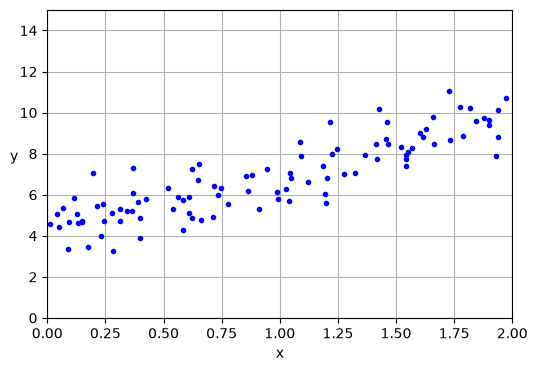

In [40]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(x,y,"b.")
plt.axis([0,2,0,15])
plt.xlabel("x")
plt.ylabel("y",rotation=0)
plt.grid()
plt.show()

In [41]:
from sklearn.preprocessing import add_dummy_feature
x_b=add_dummy_feature(x)
theta= np.linalg.inv(x_b.T @ x_b) @ x_b.T @ y 


In [42]:
theta

array([[4.21509616],
       [2.77011339]])

In [43]:
x_new = np.array([[0],[2]])
x_new_b=add_dummy_feature(x_new)
y_predict=x_new_b @ theta


In [44]:
y_predict

array([[4.21509616],
       [9.75532293]])

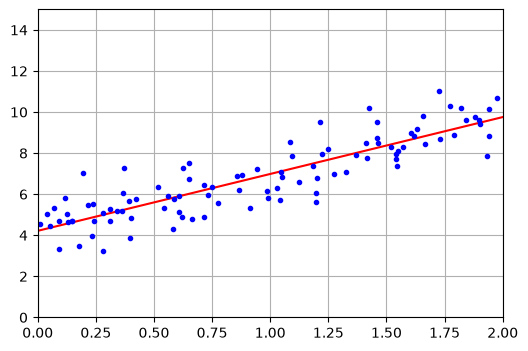

In [45]:
plt.figure(figsize=(6,4))
plt.plot(x_new,y_predict,"r-",label="Prediction")
plt.plot(x,y,'b.')
plt.axis([0,2,0,15])
plt.grid()
plt.show()

In [46]:
from sklearn.linear_model import LinearRegression

lin=LinearRegression()
lin.fit(x,y)
lin.predict(x_new)

array([[4.21509616],
       [9.75532293]])

In [47]:
lin.intercept_

array([4.21509616])

In [48]:
lin.coef_

array([[2.77011339]])

In [49]:
#batch Gradient Descent

eta =0.01
epochs=1000
np.random.seed(42)
theta=np.random.randn(2,1)

for epoch in range(epochs):
    gradients=2/m * x_b.T @(x_b @ theta -y)
    theta = theta - eta * gradients
    

In [50]:
theta


array([[4.1935218 ],
       [2.78916237]])

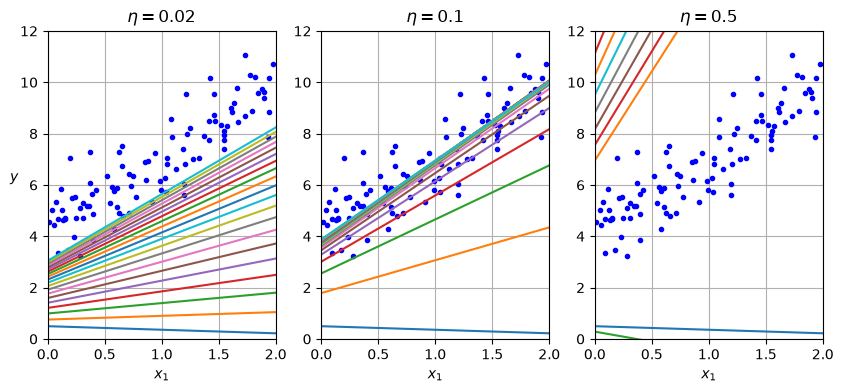

In [51]:
#ploting the graph

def plot_graph(theta,eta):
    m=len(x_b)
    epochs=1000
    n_shown=20
    theta_path=[]
    plt.plot(x,y,"b.")
    
    for epoch in range(epochs):
        if epoch < n_shown:
            y_predict=x_new_b @ theta
            plt.plot(x_new,y_predict, linestyle="solid")
        gradients=2/m *x_b.T @ (x_b @ theta -y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 12])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta=np.random.randn(2,1)

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_graph(theta,eta =0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
plot_graph(theta,eta=0.1)

plt.subplot(133)

plot_graph(theta,eta=0.5)
plt.show()

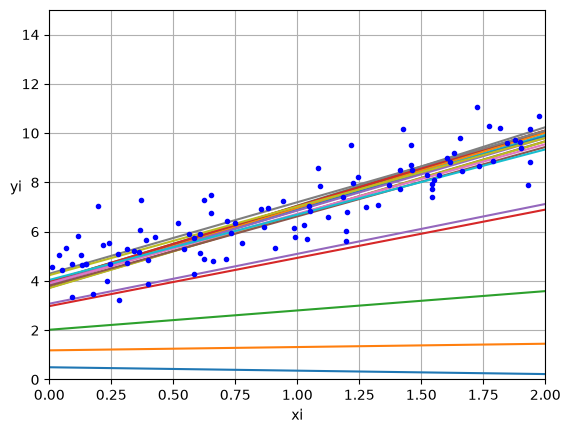

In [53]:
# stochastic Gradient Descent

epochs=50
t0,t1=5,50

def learning_rate(t):
    return t0/(t+t1)

np.random.seed(42)
theta=np.random.randn(2,1)

n_shown=20

for epoch in range(epochs):
    for iteration in range(m):
        if epoch == 0 and iteration < n_shown:

            y_predict = x_new_b @ theta
            plt.plot(x_new,y_predict)
        
        random_i= np.random.randint(m)
        xi=x_b[random_i : random_i + 1]
        yi=y[random_i : random_i + 1]

        gradients = 2*xi.T@(xi@ theta - yi)
        eta = learning_rate(epoch * m + iteration)
        theta = theta - eta * gradients
plt.plot(x,y,"b.")
plt.axis([0,2,0,15])
plt.xlabel("xi")
plt.ylabel("yi",rotation =0)
plt.grid()
plt.show()

In [54]:
theta

array([[4.21076011],
       [2.74856079]])

In [57]:
from sklearn.linear_model import SGDRegressor

SGD= SGDRegressor(max_iter=1000,penalty=None,eta0=0.01,n_iter_no_change=100,random_state=42)
SGD.fit(x,y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,42


In [58]:
SGD.intercept_,SGD.coef_

(array([4.15474433]), array([2.82564538]))